**Observações**:

* **Envio de um txt com dois links: O primeiro link para um google docs com as respostas das questões que tem explicação teórica; O segundo link para um colab com as implementações solicitadas nas questões. Por favor, coloque a identificação correta das questões se for separar em dois arquivos.**


*   As questões onde é necessário codificar devem ser feitas na linguagem de programação **python**


*   Trabalhe com as imagens em escala de cinza, exceto quando a questão indicar outro espaço de cor



**1 - O que é uma imagem digital?**

Uma imagem digital é uma representação discreta de uma cena usando uma grade de pixels. Cada pixel armazena um valor numérico que representa a intensidade luminosa (em imagens em tons de cinza) ou combinações de canais de cor (como RGB). A imagem digital é obtida a partir de uma imagem contínua por meio de amostragem e quantização, o que torna a informação discreta e armazenável em computadores.

Em termos práticos, a imagem digital pode ser vista como uma matriz 2D (escala de cinza) ou 3D (RGB, por exemplo), com valores inteiros normalmente no intervalo de 0 a 255 para imagens de 8 bits.

**2 - O que é visão computacional e por que é importante?**

Visão computacional é a área que permite que computadores analisem e interpretem imagens e vídeos, transformando informação visual em conhecimento. Ela envolve aquisição, processamento, extração de características, segmentação e reconhecimento de padrões. A importância da visão computacional está no fato de que ela automatiza tarefas que antes dependiam da percepção humana, como inspeção industrial, diagnóstico médico, identificação de objetos, carros autônomos e vigilância.

Além disso, a visão computacional é essencial para sistemas que precisam tomar decisões a partir de cenas visuais, possibilitando maior eficiência, precisão e automação em diversas áreas.

**3 - Quais são os passos fundamentais em processamento de imagens? Explique cada um deles.**

Os passos fundamentais no processamento de imagens são:

1. Aquisição: captura da imagem por câmeras, scanners ou sensores, definindo resolução e qualidade inicial.
2. Pré-processamento: ajustes iniciais para melhorar a imagem, como correção de iluminação, remoção de ruído e normalização.
3. Realce: técnicas para deixar detalhes importantes mais evidentes, como contraste, equalização de histograma e filtros.
4. Restauração: recuperação de imagens degradadas, tentando remover distorções ou ruídos.
5. Segmentação: separação da imagem em regiões ou objetos de interesse, por exemplo por limiarização.
6. Extração de características: cálculo de propriedades que descrevem a imagem, como bordas, textura, forma e histograma.
7. Reconhecimento e interpretação: classificação dos objetos ou estruturas presentes na imagem.
8. Análise final: avaliação e tomada de decisão com base nos resultados obtidos.

Esses passos não são sempre todos usados em uma mesma aplicação, mas formam a base do fluxo típico de processamento visual.

**4 - Explique os processos de amostragem e quantização para obtenção de imagens digitais. Explique também de que forma esses processos afetam a qualidade de uma imagem digital.**

Amostragem e quantização são os dois processos que transformam uma imagem contínua em uma imagem digital.

- Amostragem: consiste em converter a imagem contínua em uma grade discreta de pontos, ou seja, em pixels. A resolução espacial da imagem depende da densidade desses pontos. Quando a amostragem é baixa, há perda de detalhes e pode ocorrer aliasing.
- Quantização: consiste em converter os valores contínuos de intensidade em um conjunto finito de níveis digitais. Em imagens de 8 bits, por exemplo, há 256 níveis possíveis. Se a quantização for muito grosseira, a imagem perde nuances de intensidade e pode apresentar efeito de posterização.

A qualidade da imagem digital depende diretamente desses dois processos. Baixa amostragem reduz detalhes espaciais e baixa quantização reduz fidelidade tonal. Juntos, eles definem a aparência final da imagem e o quanto da informação original é preservada.

**5 - Abra uma imagem em escala de cinza e faça as quantizações para: 128, 64, 32, 16, 8 e 2 níveis de cinza. Mostre na tela tanto a imagem de entrada como todas as quantizações.**

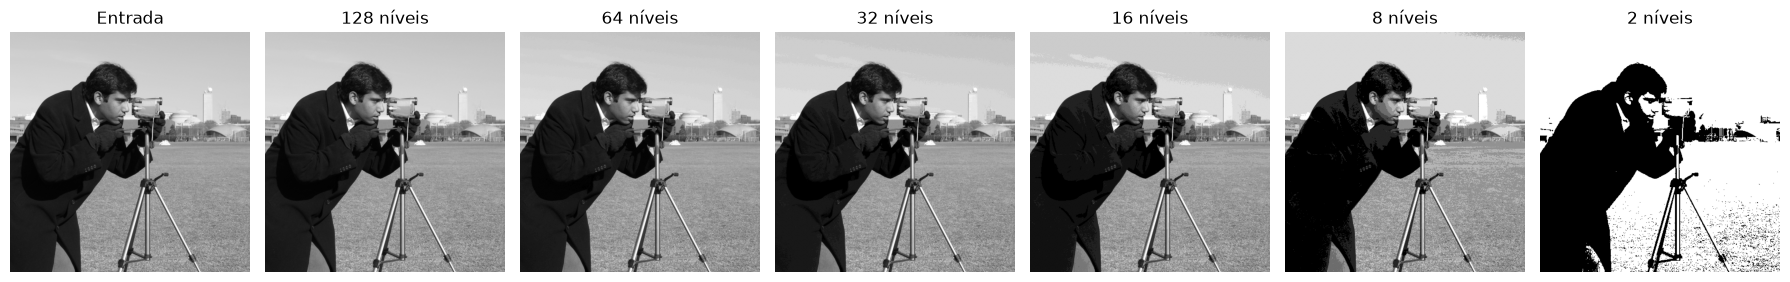

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

img = data.camera().astype(np.float32)
levels = [128, 64, 32, 16, 8, 2]

fig, axes = plt.subplots(1, len(levels) + 1, figsize=(18, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Entrada')
axes[0].axis('off')

for ax, n in zip(axes[1:], levels):
    step = 256 / n
    quantized = np.floor(img / step) * step + (step / 2)
    quantized = np.clip(quantized, 0, 255).astype(np.uint8)
    ax.imshow(quantized, cmap='gray')
    ax.set_title(f'{n} níveis')
    ax.axis('off')

plt.tight_layout()
plt.show()


**6 - Leia uma imagem colorida em RGB, crie variáveis para cada canal do RGB e mostre na tela cada um separadamente. Logo em seguida percorra e ache a maior e menor intensidade dos pixels de cada canal.**

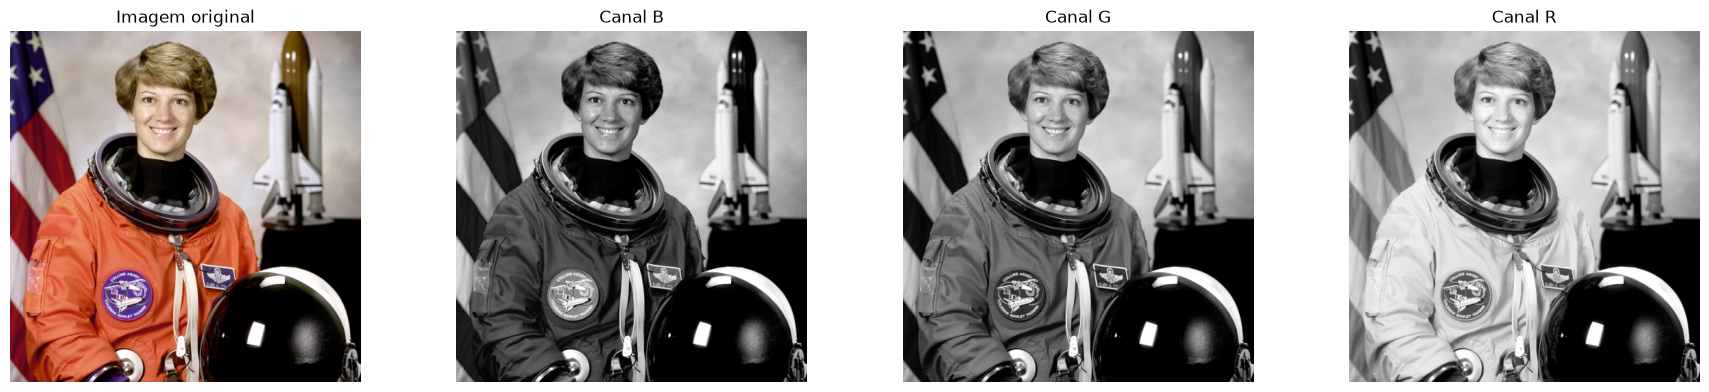

Canal B: min=0, max=255
Canal G: min=0, max=255
Canal R: min=0, max=255


In [2]:
import cv2
import matplotlib.pyplot as plt
from skimage import data

img = data.astronaut()
img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
B, G, R = cv2.split(img_bgr)

channels = {'Canal B': B, 'Canal G': G, 'Canal R': R}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(img)
axes[0].set_title('Imagem original')
axes[0].axis('off')

for ax, (name, channel) in zip(axes[1:], channels.items()):
    ax.imshow(channel, cmap='gray')
    ax.set_title(name)
    ax.axis('off')

plt.tight_layout()
plt.show()

for name, channel in channels.items():
    print(f'{name}: min={channel.min()}, max={channel.max()}')


7 - Leia uma imagem em escala de cinza e atribua o valor zero a todos os pixels cujo vizinho à direita tenha o mesmo valor de intensidade. Mostre a imagem de entrada e a imagem resultante do processo na tela.

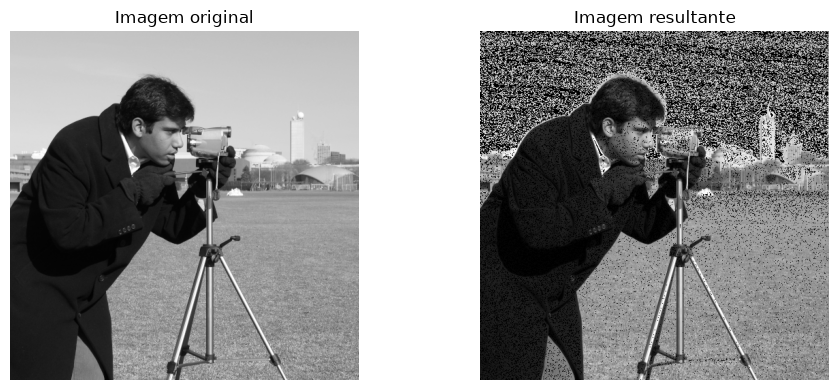

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

img = data.camera()
resultado = img.copy()
linhas, colunas = img.shape

for i in range(linhas):
    for j in range(colunas - 1):
        if img[i, j] == img[i, j + 1]:
            resultado[i, j] = 0

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Imagem original')
axes[0].axis('off')
axes[1].imshow(resultado, cmap='gray')
axes[1].set_title('Imagem resultante')
axes[1].axis('off')

plt.tight_layout()
plt.show()


8 - Leia uma imagem em escala de cinza e aplique dois métodos de binarização:

*   Limiarização com valor fixo
*   Limiarização automática utilizando o método de Otsu

Mostre na tela:

*   imagem original
*   resultado com limiar fixo
*   resultado com Otsu

Compare visualmente os resultados e informe o valor de limiar encontrado pelo método de Otsu.

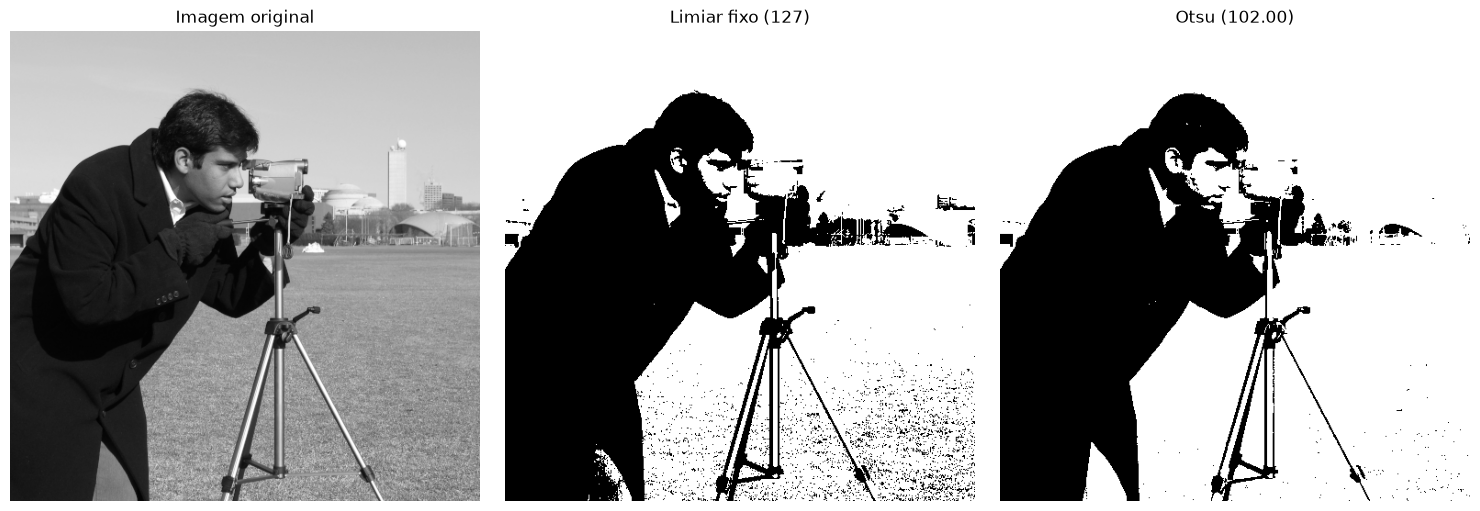

Valor de limiar encontrado pelo método de Otsu: 102.00


In [4]:
import cv2
import matplotlib.pyplot as plt
from skimage import data

img = data.camera()
limiar_fixo = 127
_, binaria_fixa = cv2.threshold(img, limiar_fixo, 255, cv2.THRESH_BINARY)
limiar_otsu, binaria_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Imagem original')
axes[0].axis('off')
axes[1].imshow(binaria_fixa, cmap='gray')
axes[1].set_title(f'Limiar fixo ({limiar_fixo})')
axes[1].axis('off')
axes[2].imshow(binaria_otsu, cmap='gray')
axes[2].set_title(f'Otsu ({limiar_otsu:.2f})')
axes[2].axis('off')

plt.tight_layout()
plt.show()
print(f'Valor de limiar encontrado pelo método de Otsu: {limiar_otsu:.2f}')


9 - Leia uma imagem colorida e converta-a para escala de cinza de três formas:

*   Utilizando a função pronta do OpenCV
*   Utilizando a fórmula matemática de conversão manual
*   Utilizando a fórmula matemática de conversão manual sem pesos nos canais

FÓRMULA: CINZA=0.2125R+0.7154G+0.0721B

Mostre na tela:

*   imagem colorida original
*   imagem em escala de cinza obtida pelo OpenCV
*   imagem em escala de cinza obtida manualmente
*   imagem em escala de cinza obtida manualmente sem pesos nos canais

Compare visualmente os resultados.
Por fim, pesquise e informe quais valores de pesos são usados na função pronta do Opencv.

Pesquisa: a função pronta do OpenCV usa, em geral, pesos aproximados de Y = 0.299R + 0.587G + 0.114B (em BGR).


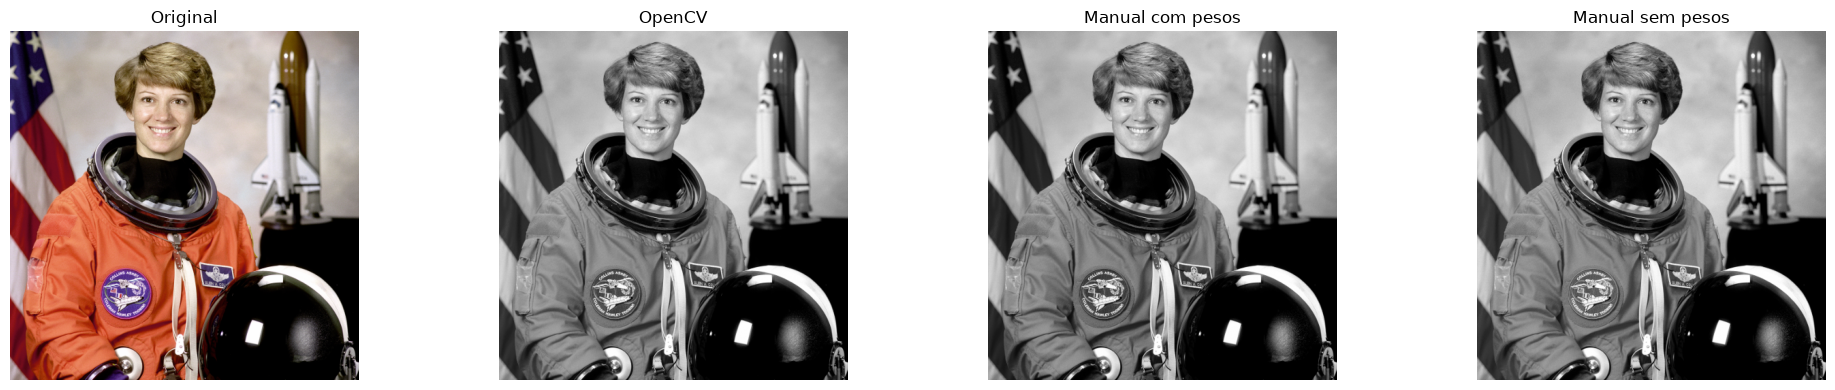

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

img = data.astronaut()
img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

# Conversão de cor para cinza usando OpenCV
cinza_cv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Conversão manual com pesos da fórmula pedida
cinza_manual = np.clip(0.2125 * img[:, :, 0] + 0.7154 * img[:, :, 1] + 0.0721 * img[:, :, 2], 0, 255).astype(np.uint8)

# Conversão manual sem pesos nos canais
cinza_sem_pesos = np.mean(img, axis=2).astype(np.uint8)

print('Pesquisa: a função pronta do OpenCV usa, em geral, pesos aproximados de Y = 0.299R + 0.587G + 0.114B (em BGR).')

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes[0].imshow(img)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(cinza_cv, cmap='gray')
axes[1].set_title('OpenCV')
axes[1].axis('off')
axes[2].imshow(cinza_manual, cmap='gray')
axes[2].set_title('Manual com pesos')
axes[2].axis('off')
axes[3].imshow(cinza_sem_pesos, cmap='gray')
axes[3].set_title('Manual sem pesos')
axes[3].axis('off')

plt.tight_layout()
plt.show()
